## Setup

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import sqlite3

print("Setup working!")

Setup working!


## Pulling Raw Data and Upload to SQL

In [2]:
tickers = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA',
    'JPM', 'BAC', 'JNJ', 'UNH', 'XOM', 'CVX', 'PG',
    'KO', 'DIS'
]



benchmark = 'SPY' 

In [3]:
all_tickers = tickers + [benchmark]
data = yf.download(all_tickers, start = '2022-01-01', end = '2026-07-01')
close_prices_raw = data['Close'].reset_index()

conn = sqlite3.connect('stock_data.db')
close_prices_raw.to_sql('prices', conn, if_exists = 'replace', index = False)

query = 'SELECT * From prices'
close_prices = pd.read_sql(query, conn, parse_dates = ['Date'], index_col = 'Date')

# date, ticker, price, long table

close_prices.head()


[*********************100%***********************]  16 of 16 completed


,AAPL,AMZN,BAC,CVX,DIS,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PG,SPY,UNH,XOM
Date,,,,,,,,,,,,,,,,
2022-01-03,177.939743,170.404495,41.265339,99.587181,151.988724,143.717117,150.902176,143.544907,51.932377,335.592987,322.462341,30.026144,144.151276,449.486511,463.212585,54.391056
2022-01-04,175.681366,167.522003,42.882717,101.399208,150.990051,143.130341,150.497528,148.986664,52.799374,333.600494,316.933075,29.197760,144.655640,449.335907,452.717743,56.436932
2022-01-05,171.008301,164.356995,42.158920,102.058914,150.466522,136.564072,151.500397,146.262848,53.237255,321.348083,304.766693,27.517067,145.310471,440.707733,451.601776,57.138863
2022-01-06,168.153580,163.253998,43.007824,102.927338,152.124451,136.536804,150.981339,147.816788,52.957008,329.565918,302.358459,28.089262,144.089310,440.293640,433.120514,58.482807
2022-01-07,168.319763,162.554001,43.946079,104.405357,153.026184,135.812714,153.022263,149.281357,52.834408,328.901703,302.512573,27.161192,144.009659,438.552979,422.929993,58.962158


## Exploratory Quieres

In [4]:
# Convert to vertical format
prices_vertical = close_prices.reset_index().melt(
    id_vars = 'Date',
    var_name = 'Ticker',
    value_name = 'Close'
)

# Load format into SQL
prices_vertical.to_sql('prices_vertical', conn, if_exists = 'replace', index = False)

prices_vertical.head()


,Date,Ticker,Close
0,2022-01-03,AAPL,177.939743
1,2022-01-04,AAPL,175.681366
2,2022-01-05,AAPL,171.008301
3,2022-01-06,AAPL,168.153580
4,2022-01-07,AAPL,168.319763


In [5]:
# Query #1: What was AAPL's highest closing price in the entire dataset?
query_1 = "SELECT MAX(Close) AS 'Highest AAPL Close Price'FROM prices_vertical WHERE Ticker = 'AAPL';"
highest_AAPL_price = pd.read_sql(query_1, conn) 
highest_AAPL_price

,Highest AAPL Close Price
0,315.200012


In [6]:
# Query #2: What are the 10 most recent trading days in the dataset?
query_2 = "SELECT DISTINCT Date AS '10 Most Recent Trading Days'FROM prices_vertical ORDER BY Date DESC LIMIT 10;"
ten_recent_trading_days = pd.read_sql(query_2, conn) 
ten_recent_trading_days

,10 Most Recent Trading Days
0,2026-06-30 00:00:00
1,2026-06-29 00:00:00
2,2026-06-26 00:00:00
3,2026-06-25 00:00:00
4,2026-06-24 00:00:00
5,2026-06-23 00:00:00
6,2026-06-22 00:00:00
7,2026-06-18 00:00:00
8,2026-06-17 00:00:00
9,2026-06-16 00:00:00


In [7]:
# Query #3 How many days did NVDA close above $100?
query_3 = "SELECT COUNT(*) AS 'Days NVDA Closed Above $100' FROM prices_vertical WHERE Ticker = 'NVDA' AND Close > 100;"
price_above_100 = pd.read_sql(query_3, conn)
price_above_100

,Days NVDA Closed Above $100
0,520


In [8]:
# Query #4 What was the average closing price for each ticker?
query_4 = "SELECT AVG(Close) AS 'Average Close Price', Ticker FROM prices_vertical GROUP BY Ticker ORDER BY AVG(Close) DESC;"
avg_close_price_per_ticker = pd.read_sql(query_4, conn)
avg_close_price_per_ticker

,Average Close Price,Ticker
0,508.343412,SPY
1,442.331199,UNH
2,426.990469,META
3,365.862064,MSFT
4,198.798145,AAPL
5,193.753068,JPM
6,171.379486,GOOGL
7,170.454488,AMZN
8,161.871027,JNJ
9,145.107622,CVX


In [9]:
# Query 5: How many days did SPY close below $400?
query_5 = "SELECT COUNT(*) AS 'Days SPY Closed Below $400' FROM prices_vertical WHERE Ticker = 'SPY' AND Close < 400;"
spy_close_below_400 = pd.read_sql(query_5, conn)
spy_close_below_400


,Days SPY Closed Below $400
0,269


## Analysis: Returns, Cumulative Returns, Plot

In [10]:
# calculate daily percentage returns
daily_returns = close_prices.pct_change()
daily_returns.head()

,AAPL,AMZN,BAC,CVX,DIS,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PG,SPY,UNH,XOM
Date,,,,,,,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.012692,-0.016916,0.039195,0.018195,-0.006571,-0.004083,-0.002682,0.037910,0.016695,-0.005937,-0.017147,-0.027589,0.003499,-0.000335,-0.022657,0.037614
2022-01-05,-0.026600,-0.018893,-0.016879,0.006506,-0.003467,-0.045876,0.006664,-0.018282,0.008293,-0.036728,-0.038388,-0.057562,0.004527,-0.019202,-0.002465,0.012437
2022-01-06,-0.016693,-0.006711,0.020136,0.008509,0.011019,-0.000200,-0.003426,0.010624,-0.005264,0.025573,-0.007902,0.020794,-0.008404,-0.000940,-0.040924,0.023521
2022-01-07,0.000988,-0.004288,0.021816,0.014360,0.005928,-0.005303,0.013518,0.009908,-0.002315,-0.002015,0.000510,-0.033040,-0.000553,-0.003953,-0.023528,0.008196


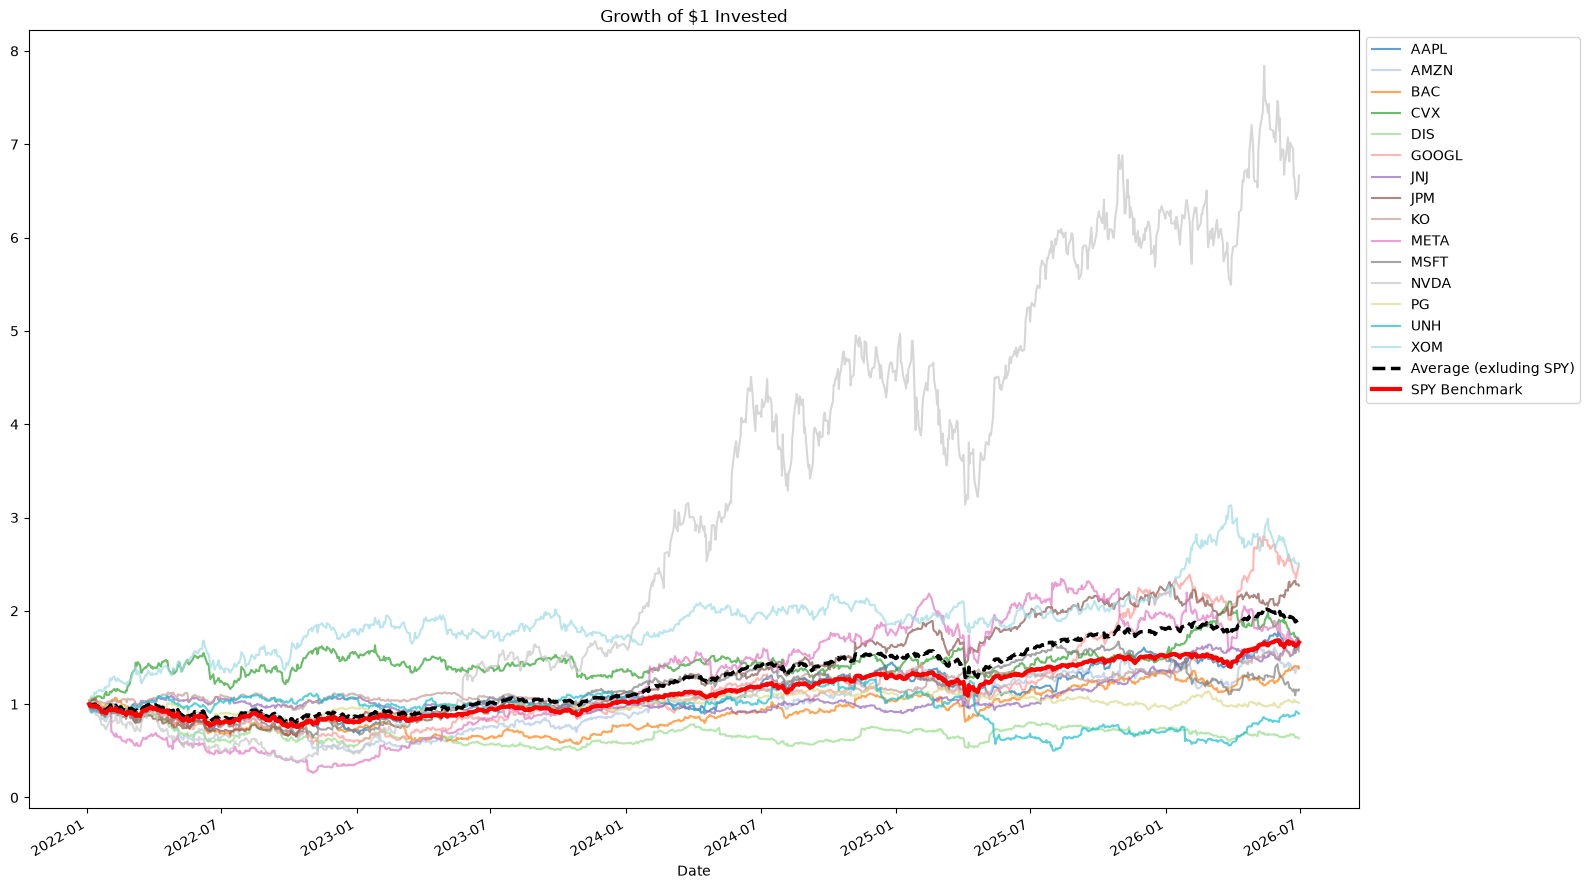

In [11]:
# Cumulative return: how $1 invested would have grown over time
cumulative_returns = (1 + daily_returns).cumprod()

fig, ax = plt.subplots(figsize = (16, 9))

# make individual stocks thinner
cumulative_returns.drop(columns = 'SPY').plot(
    ax = ax, alpha = 0.7, colormap = 'tab20'
)

# avg of all tickers 
avg_cumulative = cumulative_returns.drop(columns = 'SPY').mean(axis = 1)
avg_cumulative.plot(
    ax = ax, linewidth = 2.5, color = 'black', linestyle = '--', label = 'Average (exluding SPY)'
)

# bold spy benchmark
cumulative_returns['SPY'].plot(
    ax = ax, linewidth = 3, color = 'red', label = 'SPY Benchmark'
)

ax.set_title('Growth of $1 Invested')
ax.legend(loc = 'upper left', bbox_to_anchor = (1.0, 1.0))
plt.tight_layout()
plt.show()


## Risk Metrics: Sharpe Ratio, Max Drawdown

In [12]:
import numpy as np

sharpe_ratios = (daily_returns.mean() / daily_returns.std() * np.sqrt(252))
sharpe_ratios.sort_values(ascending = False)


NVDA     1.070536
XOM      0.907409
JPM      0.862728
GOOGL    0.789748
JNJ      0.754061
SPY      0.732931
KO       0.693004
CVX      0.575614
AAPL     0.526103
META     0.484922
BAC      0.402946
AMZN     0.387914
MSFT     0.256112
PG       0.103892
UNH      0.098264
DIS     -0.191950
dtype: float64

In [13]:
# Running max: highest value reached so far at each point in time
running_max = cumulative_returns.cummax()

# Drawdown: how far below that peak you ar eat each point in time
drawdown = (cumulative_returns - running_max) / running_max

# Max drawdown
max_drawdown = drawdown.min()
max_drawdown.sort_values(ascending = False)

KO      -0.172748
JNJ     -0.184117
XOM     -0.205087
PG      -0.237724
SPY     -0.244711
CVX     -0.249489
AAPL    -0.333605
MSFT    -0.344984
JPM     -0.379295
GOOGL   -0.436284
BAC     -0.466429
DIS     -0.497625
AMZN    -0.516759
UNH     -0.613909
NVDA    -0.616435
META    -0.735804
dtype: float64

In [14]:
# Create horizontal summary table
summary_table = pd.DataFrame({
    'Total Return': cumulative_returns.iloc[-1] - 1,
    'Sharpe Ratio': sharpe_ratios,
    'Max Drawdown': max_drawdown
})

summary_table

,Total Return,Sharpe Ratio,Max Drawdown
AAPL,0.626168,0.526103,-0.333605
AMZN,0.398672,0.387914,-0.516759
BAC,0.380820,0.402946,-0.466429
CVX,0.664471,0.575614,-0.249489
DIS,-0.366729,-0.191950,-0.497625
GOOGL,1.486621,0.789748,-0.436284
JNJ,0.683011,0.754061,-0.184117
JPM,1.270105,0.862728,-0.379295
KO,0.564920,0.693004,-0.172748
META,0.678492,0.484922,-0.735804


In [15]:
# Turn into percentages
summary_table_display = summary_table.copy()

summary_table_display['Total Return'] = (summary_table_display['Total Return'] * 100).round(1).astype(str) + '%'
summary_table_display['Max Drawdown'] = (summary_table_display['Max Drawdown'] * 100).round(1).astype(str) + '%'
summary_table_display['Sharpe Ratio'] = summary_table_display['Sharpe Ratio'].round(2)


summary_table_display


,Total Return,Sharpe Ratio,Max Drawdown
AAPL,62.6%,0.53,-33.4%
AMZN,39.9%,0.39,-51.7%
BAC,38.1%,0.40,-46.6%
CVX,66.4%,0.58,-24.9%
DIS,-36.7%,-0.19,-49.8%
GOOGL,148.7%,0.79,-43.6%
JNJ,68.3%,0.75,-18.4%
JPM,127.0%,0.86,-37.9%
KO,56.5%,0.69,-17.3%
META,67.8%,0.48,-73.6%


## Momentum Strategy

In [16]:
# resample to month-end prices
monthly_prices = close_prices.resample('ME').last()
monthly_prices.head()



,AAPL,AMZN,BAC,CVX,DIS,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PG,SPY,UNH,XOM
Date,,,,,,,,,,,,,,,,
2022-01-31,170.871368,149.573502,41.229595,109.666130,138.618439,134.114273,151.561951,132.706467,53.429920,310.533081,299.564911,24.408886,142.749817,423.328979,435.813477,65.022751
2022-02-28,161.633102,153.563004,39.496067,121.508575,143.941360,133.869965,145.700058,126.633766,54.507103,209.192993,288.417511,24.308207,138.692902,410.833466,438.856720,67.872711
2022-03-31,170.922714,162.997498,37.013294,137.397552,132.985291,137.845200,156.908447,121.739868,54.712551,220.424347,297.607025,27.204702,135.943741,426.276825,471.696106,71.481842
2022-04-30,154.320862,124.281502,32.038681,132.199692,108.232338,113.106567,159.768097,107.383934,57.015766,198.724884,267.885864,18.491745,143.640228,388.862885,470.382690,73.784088
2022-05-31,145.910934,120.209503,33.403557,148.592255,107.078568,112.762115,159.966064,118.962608,55.930351,191.954330,263.043304,18.616371,132.304642,389.740692,459.496124,83.939354


In [17]:
# 6-month momentum: how much each stock returned over the trailing 6 months
momentum = monthly_prices.pct_change(6)
momentum.head()

,AAPL,AMZN,BAC,CVX,DIS,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PG,SPY,UNH,XOM
Date,,,,,,,,,,,,,,,,
2022-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# Separate SPY out
stock_momentum = momentum.drop(columns = 'SPY')

# Rank stocks by momentum each month 
momentum_ranks = stock_momentum.rank(axis = 1, ascending = False)
momentum_ranks.dropna().head()

,AAPL,AMZN,BAC,CVX,DIS,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PG,UNH,XOM
Date,,,,,,,,,,,,,,,
2022-07-31,6.0,8.0,14.0,2.0,12.0,10.0,5.0,11.0,4.0,15.0,7.0,13.0,9.0,3.0,1.0
2022-08-31,6.0,9.0,13.0,2.0,14.0,11.0,5.0,10.0,4.0,12.0,8.0,15.0,7.0,3.0,1.0
2022-09-30,7.0,11.0,10.0,5.0,13.0,12.0,3.0,8.0,4.0,14.0,9.0,15.0,6.0,2.0,1.0
2022-10-31,7.0,13.0,5.0,2.0,8.0,12.0,6.0,4.0,9.0,15.0,11.0,14.0,10.0,3.0,1.0
2022-11-30,9.0,14.0,5.0,3.0,13.0,12.0,8.0,4.0,6.0,15.0,10.0,11.0,7.0,2.0,1.0


In [19]:
# Was this stock in the top 5 for that month?
top5_selection = momentum_ranks <= 5
top5_selection.iloc[6:12]

,AAPL,AMZN,BAC,CVX,DIS,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PG,UNH,XOM
Date,,,,,,,,,,,,,,,
2022-07-31,False,False,False,True,False,False,True,False,True,False,False,False,False,True,True
2022-08-31,False,False,False,True,False,False,True,False,True,False,False,False,False,True,True
2022-09-30,False,False,False,True,False,False,True,False,True,False,False,False,False,True,True
2022-10-31,False,False,True,True,False,False,False,True,False,False,False,False,False,True,True
2022-11-30,False,False,True,True,False,False,False,True,False,False,False,False,False,True,True
2022-12-31,False,False,True,True,False,False,False,True,False,False,False,False,True,False,True


In [20]:
# Shift down 1 because July isn't over
selected_shifted = top5_selection.shift(1)
selected_shifted.iloc[6:13]

,AAPL,AMZN,BAC,CVX,DIS,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PG,UNH,XOM
Date,,,,,,,,,,,,,,,
2022-07-31,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2022-08-31,False,False,False,True,False,False,True,False,True,False,False,False,False,True,True
2022-09-30,False,False,False,True,False,False,True,False,True,False,False,False,False,True,True
2022-10-31,False,False,False,True,False,False,True,False,True,False,False,False,False,True,True
2022-11-30,False,False,True,True,False,False,False,True,False,False,False,False,False,True,True
2022-12-31,False,False,True,True,False,False,False,True,False,False,False,False,False,True,True
2023-01-31,False,False,True,True,False,False,False,True,False,False,False,False,True,False,True


In [21]:
# Turn monthly prices into monthly returns
monthly_returns = monthly_prices.pct_change()
monthly_returns.head()

# Only keep returns for stocks that were actually selected that month
selected_returns = monthly_returns.where(selected_shifted)
selected_returns.iloc[6:13]

,AAPL,AMZN,BAC,CVX,DIS,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PG,SPY,UNH,XOM
Date,,,,,,,,,,,,,,,,
2022-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-31,NaN,NaN,NaN,-0.026156,NaN,NaN,-0.069310,NaN,-0.038336,NaN,NaN,NaN,NaN,NaN,-0.042427,-0.004242
2022-09-30,NaN,NaN,NaN,-0.091041,NaN,NaN,0.012520,NaN,-0.085587,NaN,NaN,NaN,NaN,NaN,-0.024465,-0.086620
2022-10-31,NaN,NaN,NaN,0.259135,NaN,NaN,0.064948,NaN,0.068368,NaN,NaN,NaN,NaN,NaN,0.099220,0.269156
2022-11-30,NaN,NaN,0.050222,0.021161,NaN,NaN,NaN,0.097712,NaN,NaN,NaN,NaN,NaN,NaN,-0.013312,0.012872
2022-12-31,NaN,NaN,-0.119851,-0.020839,NaN,NaN,NaN,-0.029527,NaN,NaN,NaN,NaN,NaN,NaN,-0.029111,-0.009341
2023-01-31,NaN,NaN,0.071256,-0.030475,NaN,NaN,NaN,0.051408,NaN,NaN,NaN,NaN,-0.054675,NaN,NaN,0.051768


In [22]:
# Average across the 5 picks to get one strategy return per month
strategy_returns = selected_returns.mean(axis = 1)
strategy_returns.iloc[6:13]

Date
2022-07-31         NaN
2022-08-31   -0.036094
2022-09-30   -0.055039
2022-10-31    0.152166
2022-11-30    0.033731
2022-12-31   -0.041734
2023-01-31    0.017856
Freq: ME, dtype: float64

## Momentum Strategy vs Benchmark

In [23]:
# Compound cumulative return
strategy_cumulative = (1 + strategy_returns).cumprod()
strategy_cumulative.head(10)

Date
2022-01-31         NaN
2022-02-28         NaN
2022-03-31         NaN
2022-04-30         NaN
2022-05-31         NaN
2022-06-30         NaN
2022-07-31         NaN
2022-08-31    0.963906
2022-09-30    0.910854
2022-10-31    1.049454
Freq: ME, dtype: float64

In [24]:
# SPY cumulative return
spy_cumulative = (1 + monthly_returns['SPY']).cumprod()
spy_cumulative.head(10)

Date
2022-01-31         NaN
2022-02-28    0.970483
2022-03-31    1.006963
2022-04-30    0.918583
2022-05-31    0.920657
2022-06-30    0.844739
2022-07-31    0.922529
2022-08-31    0.884888
2022-09-30    0.803084
2022-10-31    0.868355
Freq: ME, Name: SPY, dtype: float64

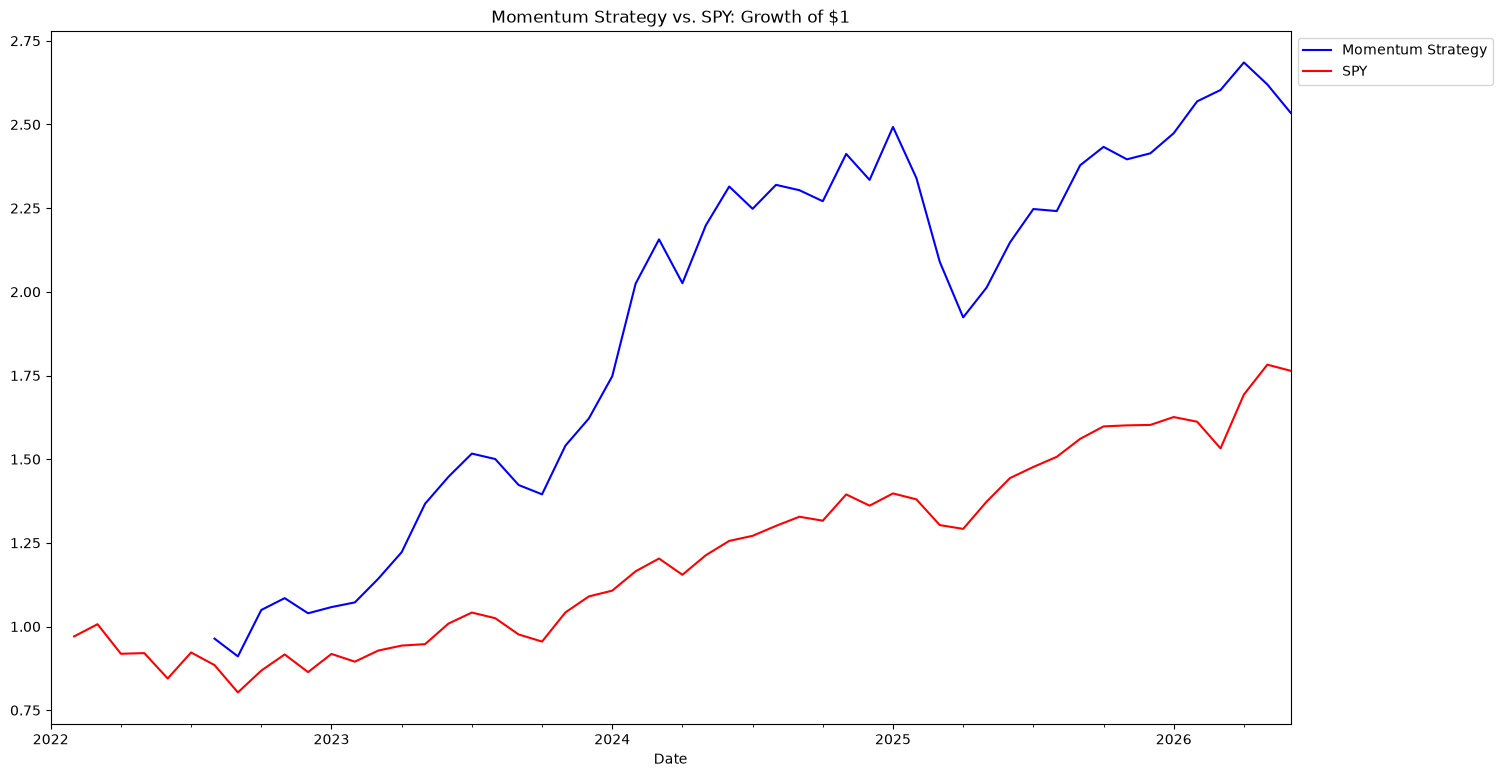

In [25]:
# Comparison plot
comparison = pd.DataFrame({
    'Momentum Strategy': strategy_cumulative,
    'SPY' : spy_cumulative
})

comparison.plot(
    figsize = (16, 9), 
    title = 'Momentum Strategy vs. SPY: Growth of $1',
    color = ['blue', 'red']
                )
plt.legend(loc = 'upper left', bbox_to_anchor = (1.0, 1.0))
plt.show()

## Risk Factors

In [26]:
# How much did NVDA play into this?

# How often was each stock actually selected?
selection_counts = selected_shifted.sum().sort_values(ascending = False)
selection_counts


NVDA     31
JPM      28
META     28
GOOGL    22
AMZN     15
MSFT     15
XOM      15
BAC      14
CVX      14
JNJ      12
AAPL     11
KO       11
UNH      10
DIS       6
PG        3
dtype: object

In [27]:
# Concentration risk
# Only looked at 15 stocks and picked the top 5 of those.
# Explain this more...

In [28]:
# Check sharpe ratios
strategy_sharpe = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(12)
spy_monthly_returns = monthly_returns['SPY']
spy_sharpe = (spy_monthly_returns.mean() / spy_monthly_returns.std()) *np.sqrt(12)

print('Strategy Sharpe Ratio: ', strategy_sharpe)
print('SPY Sharpe Ratio: ', spy_sharpe)

Strategy Sharpe Ratio:  1.2880207190886332
SPY Sharpe Ratio:  0.8859391328255508


In [29]:
# Check max drawdown
strategy_running_max = strategy_cumulative.cummax()
strategy_drawdown = (strategy_cumulative - strategy_running_max) / strategy_running_max
strategy_max_drawdown = strategy_drawdown.min()

spy_running_max = spy_cumulative.cummax()
spy_drawdown = (spy_cumulative - spy_running_max) / spy_running_max
spy_max_drawdown = spy_drawdown.min()

print('Strategy Max Drawdown: ', strategy_max_drawdown)
print('SPY Max Drawdown: ', spy_max_drawdown)



Strategy Max Drawdown:  -0.22826577059004352
SPY Max Drawdown:  -0.20246976014657245


In [30]:
strategy_vs_spy = pd.DataFrame({
    'Strategy': [strategy_cumulative.iloc[-1] - 1, strategy_sharpe, strategy_max_drawdown],
    'SPY': [spy_cumulative.iloc[-1] - 1, spy_sharpe, spy_max_drawdown]
}, index=['Total Return', 'Sharpe Ratio', 'Max Drawdown'])

strategy_vs_spy_display = strategy_vs_spy.copy().astype(object)

strategy_vs_spy_display.loc['Total Return'] = (strategy_vs_spy.loc['Total Return'] * 100).round(1).astype(str) + '%'
strategy_vs_spy_display.loc['Max Drawdown'] = (strategy_vs_spy.loc['Max Drawdown'] * 100).round(1).astype(str) + '%'
strategy_vs_spy_display.loc['Sharpe Ratio'] = strategy_vs_spy.loc['Sharpe Ratio'].round(2)

strategy_vs_spy_display


,Strategy,SPY
Total Return,153.5%,76.4%
Sharpe Ratio,1.29,0.89
Max Drawdown,-22.8%,-20.2%
